# "The effect of model resolution on air-sea CO$_{2}$ equilibration timescales "
## Code for Figure 5 f
Corresponding to Yinghuan Xie (yinghuan.xie@utas.edu.au)

In [2]:
# Importing the relevant modules.
import numpy as np
import xarray as xr
import math
import time
import datetime as dt
from datetime import timedelta
from datetime import datetime
import calendar
import os
import re
from glob import glob
#
import netCDF4 as nc
import pandas as pd
import gsw
#
import cartopy.crs as ccrs
from scipy.io import loadmat
#
import matplotlib.pyplot as plt
import matplotlib.colors as col
#
import cosima_cookbook as cc
session =cc.database.create_session() #session =cc.database.create_session('cosima_master_2022-08-30.db')
expt = '01deg_jra55v13_ryf9091'
#
from os import sys
sys.path.append('/home/581/yx9454/PhD_Ch1')
from My_Py_Func import Ch1_defs as c1d

import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

import cartopy.feature as cfeature
from PIL import Image, ImageSequence

import subprocess

import matplotlib.pyplot as plt
import numpy as np
#import mplcursors

import cftime

# Declare and load global variables

In [3]:
main_directory = '/home/581/yx9454/PhD_Ch2/JupyterLab/The-effect-of-model-resolution-on-air-sea-CO2-equilibration-timescales-'
plot_dir = '/home/581/yx9454/GBC_Revision/Plots'

sites_ordered_labels=['Iceland','Ross Sea','Weddell Sea','Eastern Antarctica','Kuroshio Current','Gulf Stream','Western Australia','Tasmania','West of Gibraltar','Hawaii','Amazon','South China Sea']
exp_hemi =  {'02':'S','03':'N','04':  'S', '05': 'N','06':'S','07':'S','08':'N','09':'S','10':'S','11':'N','12':'S','13':'S', '16':'S','17':'N','18':'N','21':'N' }
exp_name =  {'02':'Eastern Australia','03':'Hawaii','04':  'Amazon', '05': 'Iceland','06':'Ross Sea','07':'Western Australia','08':'South China Sea','09':'Chile','10':'Brazil','11':'Eastern India','12':'Weddell Sea','13':'Eastern Antarctica', '16':'Tasmania','17':'Kuroshio Current','18':'West of Gibraltar','21':'Gulf Stream'}
exp_name_1 =  {2:'Eastern Australia',3:'Hawaii',4:  'Amazon', 5: 'Iceland',6:'Ross Sea',7:'Western Australia',8:'South China Sea',9:'Chile',10:'Brazil',11:'Eastern India',12:'Weddell Sea',13:'Eastern Antarctica', 16:'Tasmania',17:'Kuroshio Current',18:'West of Gibraltar',21:'Gulf Stream'}

sites_ordered_labels=['Iceland','Ross Sea','Weddell Sea','Eastern Antarctica','Kuroshio Current','Gulf Stream','Western Australia','Tasmania','West of Gibraltar','Hawaii','Amazon','South China Sea']

site_color = {'Iceland':'b','Ross Sea':'royalblue','Weddell Sea':'deepskyblue','Eastern Antarctica':'lightskyblue',
              'Kuroshio Current':'g','Gulf Stream':'limegreen',
              'Western Australia':'gold','Tasmania':'orange','West of Gibraltar':'goldenrod',
              'Hawaii':'orangered','Amazon':'crimson','South China Sea':'red'}

# Load very fine 1/10 degree DIC deficit values, which is slightly different from 0.25Tmol. 
# This issue does not exist in 0.25 and 1-degree experiment.
file_path = '/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_REAL_Deficit_Calculation/01deg_REAL_Deficit_Calculation.csv'  
df = pd.read_csv(file_path)
# Convert the Calculation time column to datetime format
df['Calculation time'] = pd.to_datetime(df['Calculation time'])
# Group by Site No and select the row with the latest Calculation time
all_tar_data_records = df.loc[df.groupby('Site No')['Calculation time'].idxmax()]
# Record the result in the dictionary
Real_DIC_dict = dict(zip(all_tar_data_records['Site No'], all_tar_data_records['Real DIC deficit'].astype(float)))


In [4]:
df_u10 = pd.read_csv(f'{main_directory}/U10m_Analysis.csv')
df_u10['datetime'] = pd.to_datetime(df_u10['Year_Month'].str.replace('_', '-'), format='%Y-%m')
df_u10

,Resolution,Site,Year_Month,Total_surface_dic_masked,MeanU10m,datetime
0,0.1,4,2004_01,7.310505e+12,5.261637,2004-01-01
1,0.1,7,2004_01,6.587324e+12,9.667367,2004-01-01
2,0.1,12,2004_01,2.904112e+13,4.699375,2004-01-01
3,0.1,4,2004_02,1.036310e+13,5.701143,2004-02-01
4,0.1,7,2004_02,9.418045e+12,8.586435,2004-02-01
...,...,...,...,...,...,...
1723,1.0,13,2007_11,6.116981e+10,6.348576,2007-11-01
1724,1.0,21,2007_11,1.035927e+11,9.251341,2007-11-01
1725,1.0,3,2007_12,3.521844e+11,7.409120,2007-12-01
1726,1.0,13,2007_12,4.412411e+10,7.007511,2007-12-01


In [8]:
df_temp = pd.read_csv(f'{main_directory}/Mean_temp_data_Analysis.csv')
df_temp['datetime'] = pd.to_datetime(df_temp['Year_Month'].str.replace('_', '-'), format='%Y-%m')
df_temp

,Resolution,Site,Year_Month,Total_surface_dic_masked,MeanTemp,MeanTemp_whole_mask_no_weighted,datetime
0,0.1,4,2004_01,7.310505e+12,27.770847,11.698724,2004-01-01
1,0.1,7,2004_01,6.587324e+12,21.241689,23.335229,2004-01-01
2,0.1,12,2004_01,2.904112e+13,-1.263913,3.378046,2004-01-01
3,0.1,4,2004_02,1.036310e+13,27.956329,11.430536,2004-02-01
4,0.1,7,2004_02,9.418045e+12,22.015004,23.598016,2004-02-01
...,...,...,...,...,...,...,...
1723,1.0,13,2007_11,6.116981e+10,-1.559843,1.979425,2007-11-01
1724,1.0,21,2007_11,1.035927e+11,13.723944,15.788995,2007-11-01
1725,1.0,3,2007_12,3.521844e+11,25.903150,22.146082,2007-12-01
1726,1.0,13,2007_12,4.412411e+10,-0.702592,2.800348,2007-12-01


In [9]:
df_mld = pd.read_csv(f'{main_directory}/DIC_above_MLD_and_MeanMLD.csv')
df_mld['datetime'] = pd.to_datetime(df_mld['Year_Month'].str.replace('_', '-'), format='%Y-%m')
df_mld

,Resolution,Site,Year_Month,DIC_above_MLD,MeanMLD,MeanMLD_alldepth,MeanMLD_whole_mask_no_weighted,datetime
0,0.1,4,2004_01,5.197099e+13,24.405738,25.167812,77.402695,2004-01-01
1,0.1,7,2004_01,6.835823e+13,30.512170,30.165190,30.513865,2004-01-01
2,0.1,12,2004_01,5.913061e+13,7.001356,6.915767,33.096737,2004-01-01
3,0.1,4,2004_02,9.832881e+13,31.519230,30.909865,90.928550,2004-02-01
4,0.1,7,2004_02,9.790200e+13,27.990211,27.539337,31.915985,2004-02-01
...,...,...,...,...,...,...,...,...
1723,1.0,13,2007_11,4.434035e+12,300.593213,133.726758,173.598270,2007-11-01
1724,1.0,21,2007_11,3.311863e+12,131.083973,64.367624,46.298980,2007-11-01
1725,1.0,3,2007_12,8.523698e+12,78.835713,59.550820,39.225940,2007-12-01
1726,1.0,13,2007_12,2.805517e+11,30.930184,28.444458,46.665672,2007-12-01


In [10]:
df_k_ddic = pd.read_csv(f'{main_directory}/Mean_k_ddic_Analysis.csv')
df_k_ddic['datetime'] = pd.to_datetime(df_k_ddic['Year_Month'].str.replace('_', '-'), format='%Y-%m')
df_k_ddic

,Resolution,Site,Year_Month,Total_surface_dic_masked,Mean_k_ddic,datetime
0,0.1,4,2004_01,7.310505e+12,0.493845,2004-01-01
1,0.1,7,2004_01,6.587324e+12,1.650192,2004-01-01
2,0.1,12,2004_01,2.904112e+13,0.726078,2004-01-01
3,0.1,4,2004_02,1.036310e+13,0.587634,2004-02-01
4,0.1,7,2004_02,9.418045e+12,1.333942,2004-02-01
...,...,...,...,...,...,...
1723,1.0,13,2007_11,6.116981e+10,1.460549,2007-11-01
1724,1.0,21,2007_11,1.035927e+11,1.927859,2007-11-01
1725,1.0,3,2007_12,3.521844e+11,1.007713,2007-12-01
1726,1.0,13,2007_12,4.412411e+10,1.690064,2007-12-01


In [11]:
df_PACO2 = pd.read_csv(f'{main_directory}/Mean_PACO2_times_Area_data_Analysis.csv')
df_PACO2['datetime'] = pd.to_datetime(df_PACO2['Year_Month'].str.replace('_', '-'), format='%Y-%m')
df_PACO2

,Resolution,Site,Year_Month,Total_PACO2_times_area,datetime
0,0.1,4,2004_01,5.307971e+12,2004-01-01
1,0.1,7,2004_01,4.791046e+12,2004-01-01
2,0.1,12,2004_01,2.707890e+13,2004-01-01
3,0.1,4,2004_04,5.674766e+12,2004-04-01
4,0.1,7,2004_04,3.526110e+12,2004-04-01
...,...,...,...,...,...
553,1.0,13,2007_07,7.463994e+10,2007-07-01
554,1.0,21,2007_07,8.006560e+10,2007-07-01
555,1.0,3,2007_10,2.472567e+11,2007-10-01
556,1.0,13,2007_10,8.435986e+10,2007-10-01


# Figure S7 (a)
Timeseries for CO2 Deficit Residual above MLD

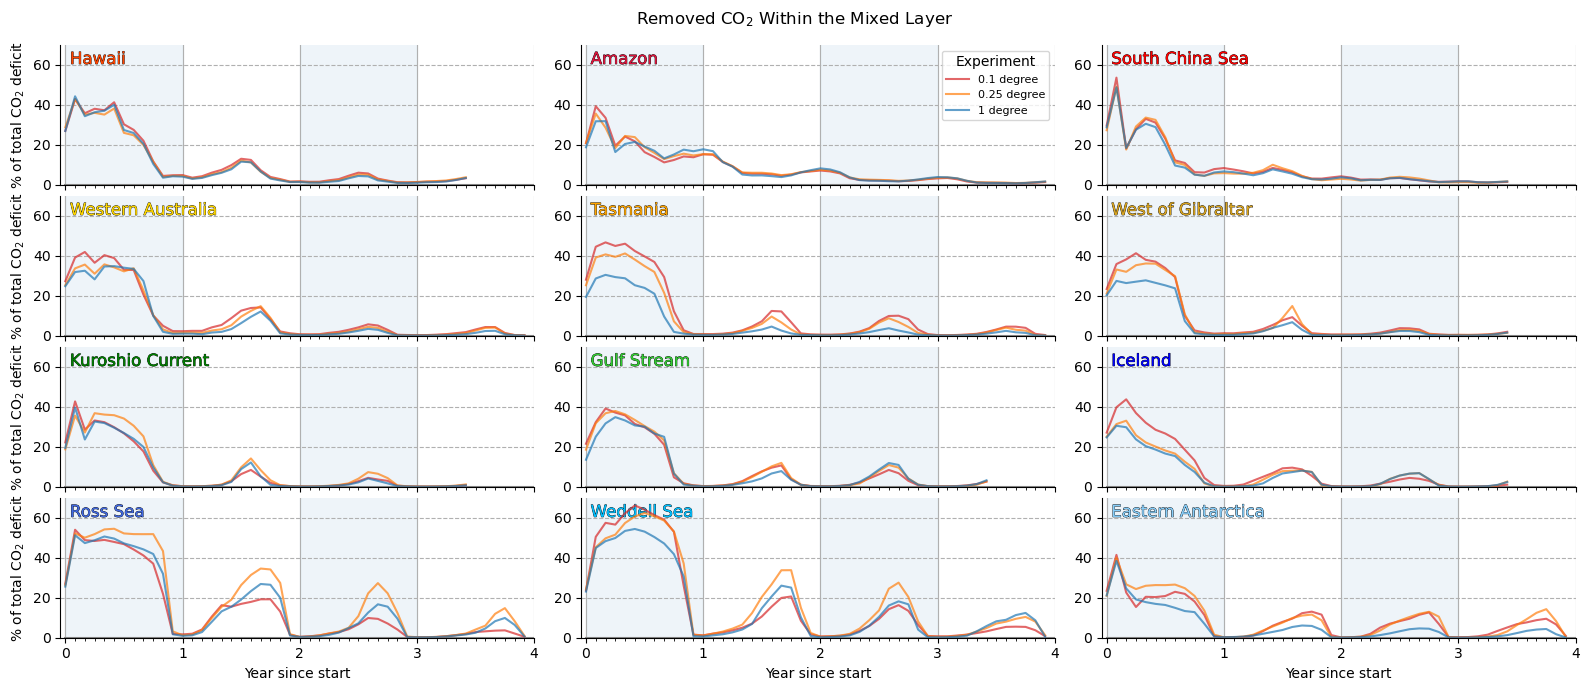

In [14]:
df = df_mld
key_word = 'DIC_above_MLD' # MeanMLD_alldepth or MeanMLD
import matplotlib.patheffects as path_effects

# date conversion
df['datetime'] = pd.to_datetime(df['Year_Month'].str.replace('_', '-'), format='%Y-%m')

# Define the site list and the resolution list
sites = [3, 4, 5, 6, 7, 12, 13, 16, 17, 18, 21, 8]
resolutions = [1.0, 0.25, 0.1]
colors = {1: 'C0', 0.25: 'C1', 0.1: 'C3'}
plot_idx = {'03':0,'04':1,'08':2,'07':3,'16':4,'18':5,'17':6,'21':7,'05':8,'06':9,'12':10,'13':11}

fig, axes = plt.subplots(4, 3, figsize=(16,7))
fig.suptitle(r'Removed $\mathrm{CO_2}$ Within the Mixed Layer', fontsize=12)
axes = axes.flatten()
for idx, site in enumerate(sites):
    ax = axes[plot_idx[f"{site:02d}"]]
    site_data = df[df['Site'] == site]
    if site_data.empty:
        ax.set_title(f"Site {site}: no data")
        continue
    # Ordering in Time
    site_data = site_data.sort_values(by='datetime')
    start_date = datetime(2004, 7, 1) if exp_hemi[f"{site:02d}"] == 'N' else datetime(2004, 1, 1)
    date_to_month = lambda d: (d.year - start_date.year) * 12 + (d.month - start_date.month)
    month_indices = [date_to_month(d) for d in site_data[site_data['Resolution']==0.1]['datetime']]

    data_01,data025,data10 = (site_data[site_data['Resolution'] == 0.1][key_word],
                         site_data[site_data['Resolution'] == 0.25][key_word],
                         site_data[site_data['Resolution'] == 1][key_word])
    mean_data = np.nanmean(np.vstack([data_01,data025,data10]), axis=0)
    std_data = np.nanstd(np.vstack([data_01, data025, data10]), axis=0)
    std_data[np.array(month_indices)<0] = np.nan

    for res, data in zip([0.1,0.25,1], [data_01, data025, data10]):
        tar = data.copy()#(data-mean_data),fontsize=10
        tar[np.array(month_indices)<0] = np.nan
        ax.plot(month_indices, tar/(2.5e14)*100,
                    label=f"{res} degree", color=colors[res],zorder=10, alpha=0.7)
        
    ax.text(0.02, 0.95, exp_name_1[site], color=site_color[exp_name_1[site]], path_effects=[path_effects.withStroke(linewidth=0.5, foreground='black')], transform=ax.transAxes, ha='left', va='top',fontsize=12)

    if plot_idx[f"{site:02d}"] in [0,3,6,9]:
        ax.set_ylabel(r'% of total $\mathrm{CO_2}$ deficit')
    if plot_idx[f"{site:02d}"] in [9,10,11]:
        ax.set_xlabel("Year since start")
    ax.grid(True,zorder=0)
    ax.grid(axis='y', linestyle='--')
    if plot_idx[f"{site:02d}"] in [1]:
        ax.legend(
            title='Experiment',
            fontsize=8,           # Legend text font size
            title_fontsize=10,      # Legend title font size
            loc='upper right'
        )
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.set_ylim(0,70)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    for year in np.arange(0,48,24):
        ax.fill_between([year,year+12], [-3e10,-3e10],[3e10,3e10], alpha=0.075,zorder=0,color='C0')
    ax.plot([0,48],[0,0],linestyle='-',color='grey',zorder=5)

    # Set the X-axis: -0.1 to 48 months, with one minor tick per month and one major tick every three months
    ax.set_xlim(-0.5, 48)
    ax.set_xticks(np.arange(0, 49, 1), minor=True)
    major_ticks = np.arange(0, 49, 12)
    ax.set_xticks(major_ticks)
    ax.set_xticklabels([str(i) for i in range(len(major_ticks))])  # 显示为0,1,2,3,4
    if plot_idx[f"{site:02d}"] < 9:
        ax.set_xticklabels([])
    
fig.tight_layout()
plt.subplots_adjust(hspace=0.08)
#plt.savefig(f'{main_directory}/Plots/Mean_Removed_CO2_Within_the_Mixed_Layer.png',dpi=300)
plt.show()

## Figure 5 (f)

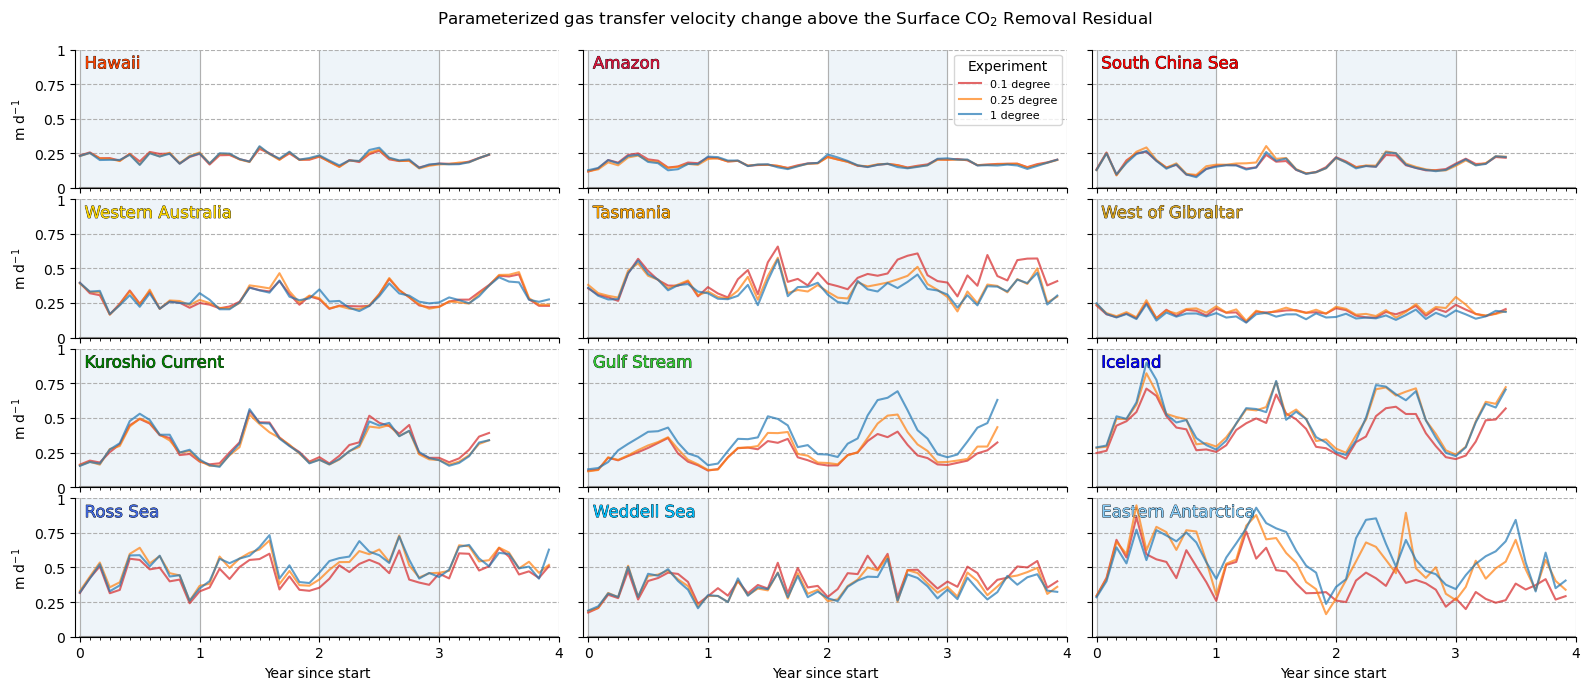

In [17]:
df = df_k_ddic
key_word = 'Mean_k_ddic' # MeanMLD_alldepth or MeanMLD
import matplotlib.patheffects as path_effects

# date conversion
df['datetime'] = pd.to_datetime(df['Year_Month'].str.replace('_', '-'), format='%Y-%m')

# Define the site list and the resolution list
sites = [3, 4, 5, 6, 7, 12, 13, 16, 17, 18, 21, 8]
resolutions = [1.0, 0.25, 0.1]
colors = {1: 'C0', 0.25: 'C1', 0.1: 'C3'}

plot_idx = {'03':0,'04':1,'08':2,'07':3,'16':4,'18':5,'17':6,'21':7,'05':8,'06':9,'12':10,'13':11}
fig, axes = plt.subplots(4, 3, figsize=(16,7))
fig.suptitle(r'Parameterized gas transfer velocity change above the Surface $\mathrm{CO_2}$ Removal Residual', fontsize=12)
axes = axes.flatten()

for idx, site in enumerate(sites):
    ax = axes[plot_idx[f"{site:02d}"]]
    site_data = df[df['Site'] == site]
    if site_data.empty:
        ax.set_title(f"Site {site}: no data")
        continue

    # Ordering in Time
    site_data = site_data.sort_values(by='datetime')
    start_date = datetime(2004, 7, 1) if exp_hemi[f"{site:02d}"] == 'N' else datetime(2004, 1, 1)
    date_to_month = lambda d: (d.year - start_date.year) * 12 + (d.month - start_date.month)
    month_indices = [date_to_month(d) for d in site_data[site_data['Resolution']==0.1]['datetime']]

    data_01,data025,data10 = (site_data[site_data['Resolution'] == 0.1][key_word],
                         site_data[site_data['Resolution'] == 0.25][key_word],
                         site_data[site_data['Resolution'] == 1][key_word])
    mean_data = np.nanmean(np.vstack([data_01,data025,data10]), axis=0)
    std_data = np.nanstd(np.vstack([data_01, data025, data10]), axis=0)
    std_data[np.array(month_indices)<0] = np.nan
    
    for res, data in zip([0.1,0.25,1], [data_01, data025, data10]):
        tar = data.copy()#(data-mean_data),fontsize=10
        tar[np.array(month_indices)<0] = np.nan
        ax.plot(month_indices, 0.24*tar,
                    label=f"{res} degree", color=colors[res],zorder=10, alpha=0.7)
    ax.text(0.02, 0.95, exp_name_1[site], color=site_color[exp_name_1[site]], path_effects=[path_effects.withStroke(linewidth=0.5, foreground='black')], transform=ax.transAxes, ha='left', va='top',fontsize=12)

    if plot_idx[f"{site:02d}"] in [0,3,6,9]:
        ax.set_ylabel(r'm $\mathrm{d}^{-1}$')
    if plot_idx[f"{site:02d}"] in [9,10,11]:
        ax.set_xlabel("Year since start")
    ax.grid(True,zorder=0)
    ax.grid(axis='y', linestyle='--')
    if plot_idx[f"{site:02d}"] in [1]:
        ax.legend(
            title='Experiment',
            fontsize=8,           # 
            title_fontsize=10,      # 
            loc='upper right'
        )
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.set_ylim(0, 1)    
    #ax.set_yscale('log')
    #ax.set_ylim(0.01, 6)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y:.12g}'))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    if plot_idx[f"{site:02d}"] in [1,2,4,5,7,8,10,11]:
        ax.set_yticklabels([])
        
    for year in np.arange(0,48,24):
        ax.fill_between([year,year+12], [-3e10,-3e10],[3e10,3e10], alpha=0.075,zorder=0,color='C0')
    ax.plot([0,48],[0,0],linestyle='-',color='grey',zorder=5)
    # Set the X-axis: -0.1 to 48 months, with one minor tick per month and one major tick every three months
    ax.set_xlim(-0.5, 48)
    ax.set_xticks(np.arange(0, 49, 1), minor=True)
    major_ticks = np.arange(0, 49, 12)
    ax.set_xticks(major_ticks)
    ax.set_xticklabels([str(i) for i in range(len(major_ticks))])  # 显示为0,1,2,3,4
    if plot_idx[f"{site:02d}"] < 9:
        ax.set_xticklabels([])
        
fig.tight_layout()
plt.subplots_adjust(hspace=0.08) 
#plt.savefig(f'{main_directory}/Mean_k_ddic_Across_the_Surface_CO2_removal_Residual.png',dpi=300)
plt.show()